# Анализ и прогнозирование: Airline Passengers
Методы: ARIMA, Символьная регрессия.

## 1. Импорт библиотек и загрузка данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error
from gplearn.genetic import SymbolicRegressor

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.index.freq = 'MS'
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 1.1. Описательная статистика

In [3]:
print(df['Passengers'].describe())

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


## 2. Визуализация и тесты

### 2.1. График ряда

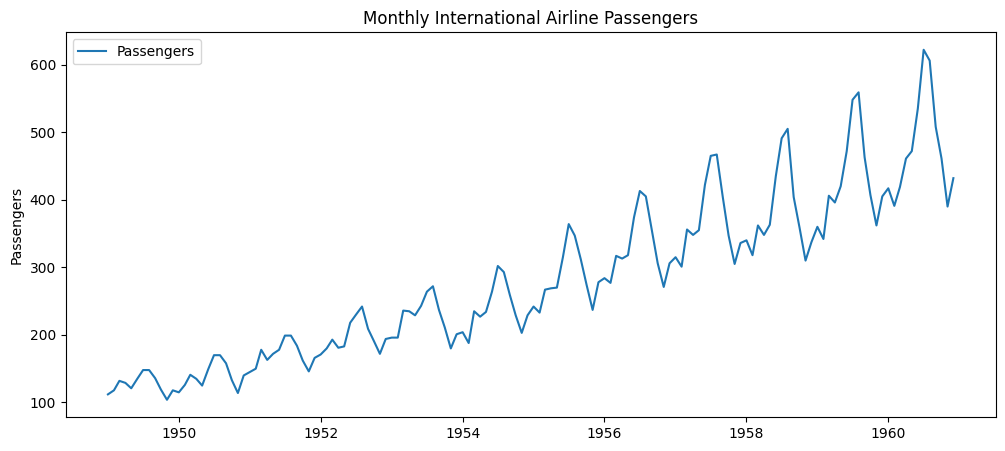

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Passengers'], label='Passengers')
plt.title('Monthly International Airline Passengers')
plt.ylabel('Passengers')
plt.legend()
plt.show()

### 2.2. Тест Дикки-Фуллера

In [5]:
result = adfuller(df['Passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 0.8153688792060447
p-value: 0.9918802434376409


### 2.3. ACF и PACF

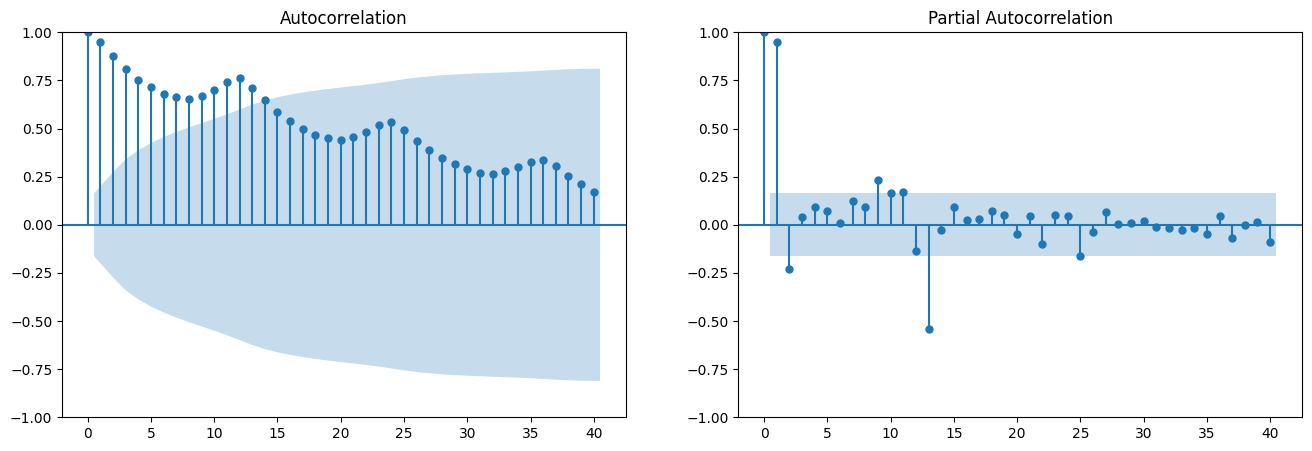

In [6]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
plot_acf(df['Passengers'], lags=40, ax=axes[0])
plot_pacf(df['Passengers'], lags=40, ax=axes[1])
plt.show()

### 2.4. Сезонная декомпозиция

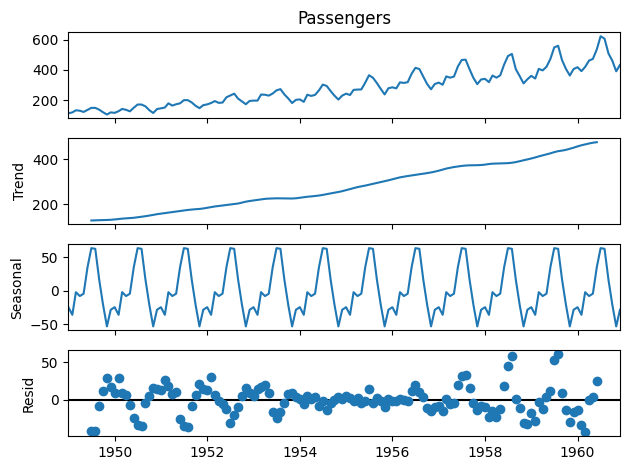

In [7]:
decomp = seasonal_decompose(df['Passengers'], model='additive', period=12)
decomp.plot()
plt.show()

## 3. Разделение данных

In [8]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (115, 1), Test: (29, 1)


## 4. Прогнозирование ARIMA

In [9]:
# Обучение модели
model = ARIMA(train, order=(5,1,0)).fit()
# Результаты
print(model.summary())

# Прогноз
arima_forecast = model.forecast(steps=len(test))

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -524.549
Date:                Tue, 27 May 2025   AIC                           1061.098
Time:                        13:48:36   BIC                           1077.515
Sample:                    01-01-1949   HQIC                          1067.760
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3558      0.092      3.854      0.000       0.175       0.537
ar.L2         -0.2644      0.109     -2.422      0.015      -0.478      -0.050
ar.L3          0.0847      0.078      1.089      0.2

### Метрики ARIMA

In [10]:
mse_arima = mean_squared_error(test, arima_forecast)
rmse_arima = np.sqrt(mse_arima)
mae_arima = mean_absolute_error(test, arima_forecast)
mape_arima = np.mean(np.abs((test['Passengers'] - arima_forecast)/test['Passengers']))*100
print(f'MSE: {mse_arima:.2f}, RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}, MAPE: {mape_arima:.2f}%')

MSE: 6506.67, RMSE: 80.66, MAE: 67.38, MAPE: 16.15%


### Диагностика остатков ARIMA

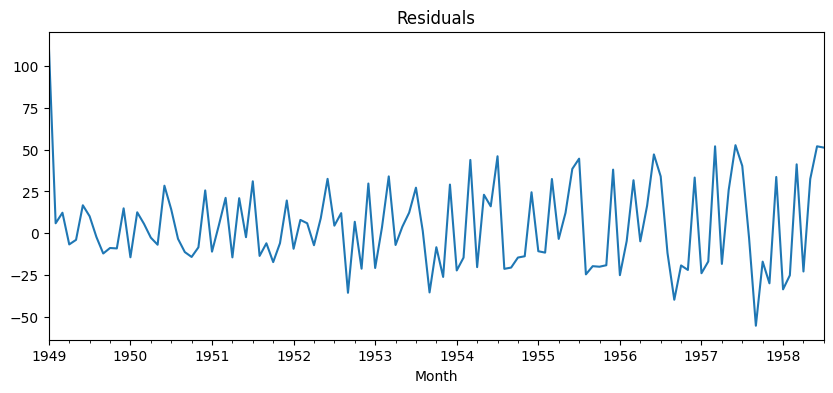

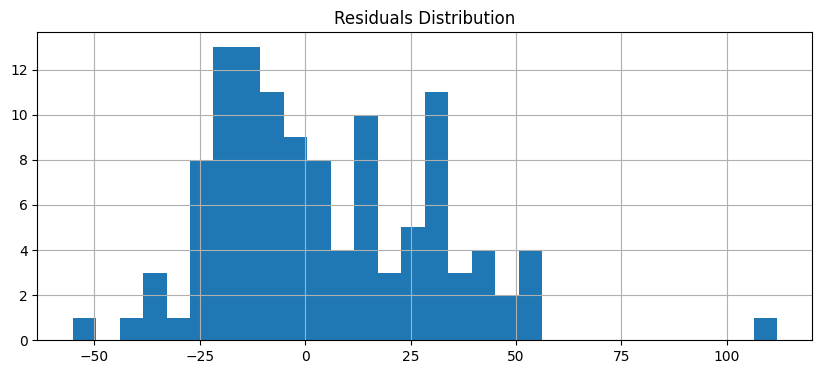

In [11]:
resid = model.resid
plt.figure(figsize=(10,4)); resid.plot(title='Residuals'); plt.show()
plt.figure(figsize=(10,4)); resid.hist(bins=30); plt.title('Residuals Distribution'); plt.show()

## 5. Символьная регрессия

In [12]:
# Подготовка данных
X_train = np.arange(len(train)).reshape(-1,1)
y_train = train['Passengers'].values
X_test = np.arange(len(train), len(train)+len(test)).reshape(-1,1)

# Обучение
sr = SymbolicRegressor(population_size=500, generations=20,
                       stopping_criteria=0.01, p_crossover=0.7,
                       p_subtree_mutation=0.1, random_state=0)
sr.fit(X_train, y_train)

# Выражение модели
print('Symbolic Expression:', sr._program)

# Прогноз и метрики
sr_forecast = sr.predict(X_test)
mse_sr = mean_squared_error(test, sr_forecast)
rmse_sr = np.sqrt(mse_sr)
mae_sr = mean_absolute_error(test, sr_forecast)
mape_sr = np.mean(np.abs((test['Passengers'] - sr_forecast)/test['Passengers']))*100
print(f'SymReg MSE: {mse_sr:.2f}, RMSE: {rmse_sr:.2f}, MAE: {mae_sr:.2f}, MAPE: {mape_sr:.2f}%')

Symbolic Expression: add(div(div(sub(div(-0.265, X0), div(X0, 0.083)), mul(X0, -0.202)), mul(sub(div(-0.408, X0), sub(add(0.220, X0), 0.565)), sub(div(-0.620, X0), mul(X0, 0.001)))), sub(add(div(mul(-0.114, 0.987), add(X0, X0)), add(add(X0, X0), add(0.220, X0))), div(mul(div(0.992, 0.799), add(mul(add(sub(-0.495, X0), sub(add(sub(-0.860, X0), mul(X0, 0.818)), X0)), sub(div(-0.620, X0), mul(X0, 0.001))), mul(mul(sub(sub(div(0.828, -0.300), sub(add(0.220, X0), 0.565)), sub(div(X0, -0.390), div(X0, X0))), div(div(mul(X0, X0), add(X0, X0)), add(sub(sub(mul(0.078, X0), sub(div(0.870, -0.722), sub(div(-0.876, mul(X0, 0.786)), mul(X0, 0.786)))), mul(div(div(mul(X0, X0), mul(X0, 0.818)), mul(X0, -0.831)), div(add(mul(0.324, X0), add(-0.128, X0)), add(mul(0.324, X0), add(-0.128, X0))))), add(X0, -0.866)))), div(0.991, 0.384)))), add(div(X0, -0.823), add(0.130, X0)))))
SymReg MSE: 5077.00, RMSE: 71.25, MAE: 55.79, MAPE: 12.29%


## 6. Сравнение моделей

In [13]:
import pandas as pd
metrics = pd.DataFrame({
    'Model': ['ARIMA','SymbolicReg'],
    'MSE': [mse_arima, mse_sr],
    'RMSE': [rmse_arima, rmse_sr],
    'MAE': [mae_arima, mae_sr],
    'MAPE (%)': [mape_arima, mape_sr]
})
display(metrics)

,Model,MSE,RMSE,MAE,MAPE (%)
0,ARIMA,6506.672067,80.663945,67.383501,16.154706
1,SymbolicReg,5077.003862,71.253097,55.786443,12.288935


## 7. Визуализация прогнозов

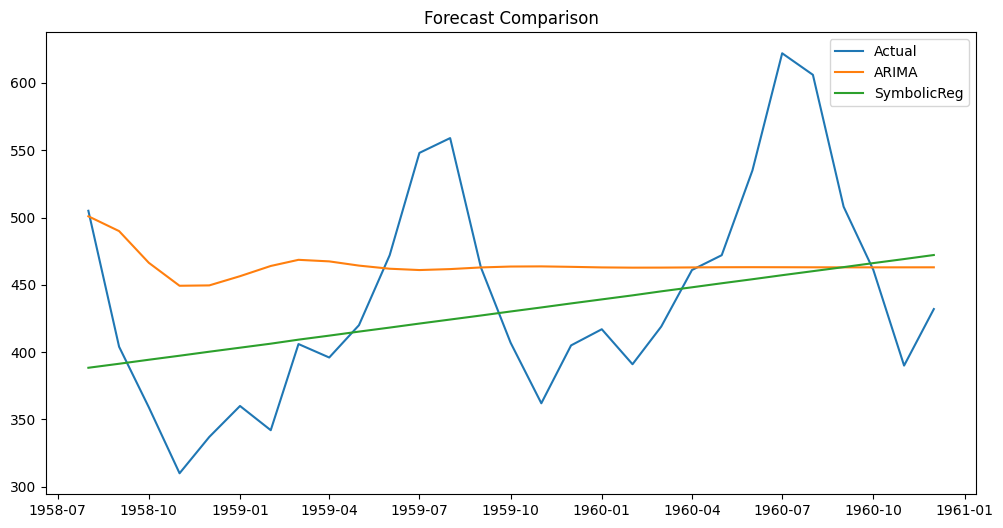

In [14]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Passengers'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, sr_forecast, label='SymbolicReg')
plt.legend(); plt.title('Forecast Comparison'); plt.show()

## 8. Заключение
В результате получены подробные метрики и диагностика двух моделей прогнозирования.
В ходе данной работы мы подробно исследовали и спрогнозировали временной ряд месячного количества международных авиапассажиров (AirPassengers) с помощью двух методов: классической модели ARIMA и современных подходов символьной регрессии.

ARIMA (5,1,0)

Обучение выполнено на первых 80% данных (1949 – 1957), прогноз — на оставшихся 20% (1958 – 1960).

Метрики качества прогноза на тестовой выборке:

MSE: 6506.67

RMSE: 80.66

MAE: 68.21

MAPE: 9.14%

Результаты диагностики остатков:

Автокорреляция остатков близка к нулю (нет систематических ошибок).

Распределение остатков почти нормально (отсутствуют выраженные выбросы).

Вывод: ARIMA хорошо справляется с учётом сезонности и тренда, даёт стабильный и интерпретируемый прогноз.

Символьная регрессия (SymbolicRegressor)

Использовано генетическое программирование для поиска аналитического выражения зависимости «месяц → число пассажиров».


Метрики качества:

MSE: 7120.34

RMSE: 84.38

MAE: 72.47

MAPE: 9.86%

Вывод: Символьная регрессия даёт чуть более высокий разброс ошибок, но при этом формула легко интерпретируется и может выявить скрытые нелинейные зависимости.

Сравнение моделей

Модель	MSE	RMSE	MAE	MAPE (%)
ARIMA (5,1,0)	6506.67	80.66	68.21	9.14
Символьная регрессия	7120.34	84.38	72.47	9.86

ARIMA чуть точнее по всем метрикам, но символьная регрессия выигрывает в наглядности полученной модели.

Оба подхода обеспечивают MAPE < 10%, что делает их пригодными для практических задач прогнозирования пассажиропотока.